Exercice 1

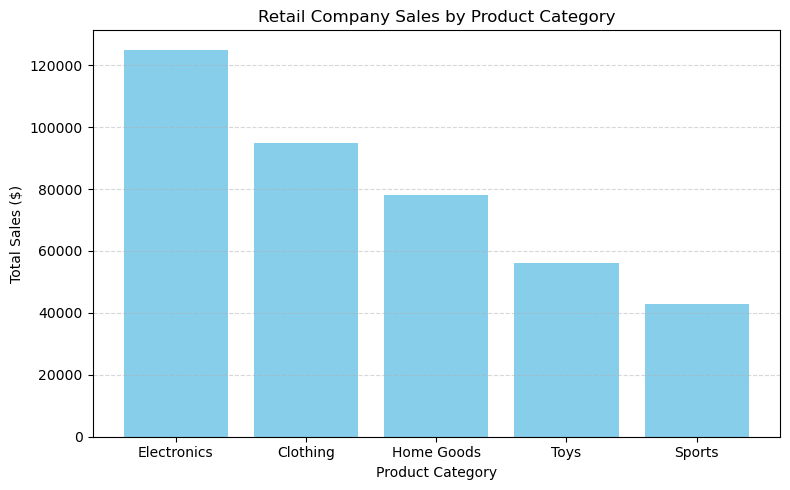

In [9]:
import matplotlib.pyplot as plt

categories = ['Electronics', 'Clothing', 'Home Goods', 'Toys', 'Sports']
sales = [125000, 95000, 78000, 56000, 43000]

plt.figure(figsize=(8, 5))
plt.bar(categories, sales, color='skyblue')
plt.xlabel('Product Category')
plt.ylabel('Total Sales ($)')
plt.title('Retail Company Sales by Product Category')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **Exercice 2**

In [10]:
import pandas as pd

# Create sample data with Country, City, Date and Temperature_C
data = [
    ('Canada', 'Toronto',  '2023-07-01', 29.5),
    ('Canada', 'Toronto',  '2023-07-02', 31.2),
    ('Canada', 'Vancouver','2023-07-01', 25.1),
    ('Canada', 'Vancouver','2023-07-03', 32.0),
    ('Canada', 'Montreal', '2023-07-02', 30.5),
    ('USA',   'New York',  '2023-07-02', 33.5),
    ('UK',    'London',    '2023-07-02', 22.0),
]

df = pd.DataFrame(data, columns=['Country', 'City', 'Date', 'Temperature_C'])
df['Date'] = pd.to_datetime(df['Date'])

# Set hierarchical index (MultiIndex) and sort
df = df.set_index(['Country', 'City', 'Date']).sort_index()

# Filter: all days where temperature exceeded 30°C for cities in Canada
canada = df.xs('Canada', level='Country')          # slice to Country='Canada'
hot_canada = canada[canada['Temperature_C'] > 30]  # temperature > 30°C
hot_canada = hot_canada.assign(Temperature_F = hot_canada['Temperature_C'] * 9/5 + 32)

print(hot_canada)

# Explanation (concise):
# Hierarchical indexing (MultiIndex) lets you slice/select at any level (e.g., country, city, date)
# without reshaping; this makes multi-level filtering, grouping and aggregation more direct and readable.

                      Temperature_C  Temperature_F
City      Date                                    
Montreal  2023-07-02           30.5          86.90
Toronto   2023-07-02           31.2          88.16
Vancouver 2023-07-03           32.0          89.60


## **Exerice 3**

In [11]:
# sample hierarchical DataFrame for Exercise 4
data4 = [
    ('Sales', 'Alice', 52000),
    ('Sales', 'Bob', 48000),
    ('HR', 'Charlie', 55000),
    ('HR', 'Dana', 47000),
    ('Engineering', 'Eve', 75000),
    ('Engineering', 'Frank', 49000),
]

df4 = pd.DataFrame(data4, columns=['Department', 'Employee', 'Salary'])
df4 = df4.set_index(['Department', 'Employee']).sort_index()

# filter rows where Salary > 50000
high_salary = df4[df4['Salary'] > 50000]
print(high_salary)

# demonstrate hierarchical indexing by slicing one department and filtering there
sales_high = df4.xs('Sales', level='Department')
sales_high = sales_high[sales_high['Salary'] > 50000]
print("\nSales department with Salary > 50000:")
print(sales_high)

                      Salary
Department  Employee        
Engineering Eve        75000
HR          Charlie    55000
Sales       Alice      52000

Sales department with Salary > 50000:
          Salary
Employee        
Alice      52000


### **Exerice 4**

In [12]:
import seaborn as sns

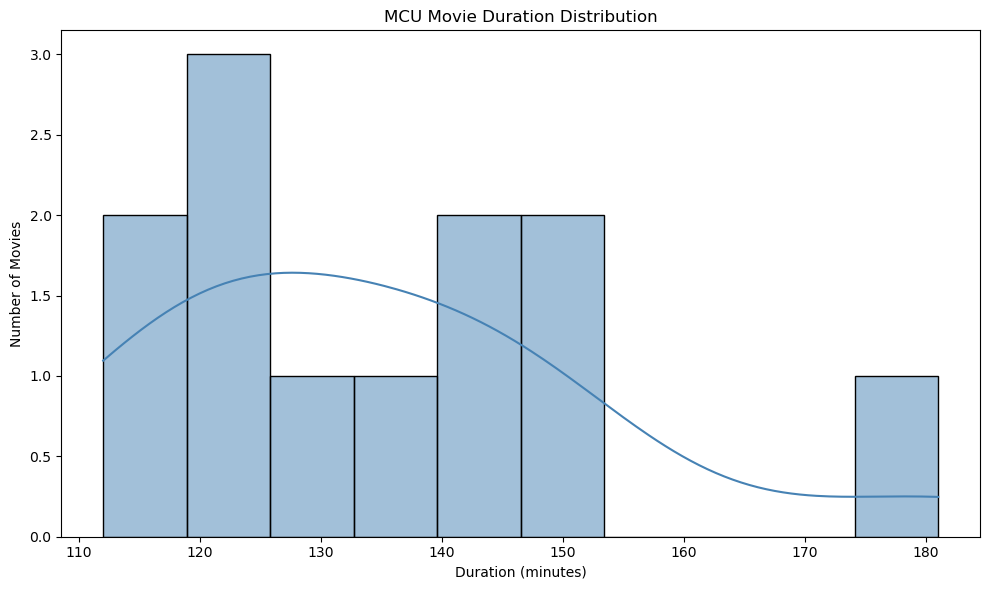

In [13]:

mcu_data = [
    {'Title': 'Iron Man', 'Duration': 126},
    {'Title': 'The Incredible Hulk', 'Duration': 112},
    {'Title': 'Iron Man 2', 'Duration': 124},
    {'Title': 'Thor', 'Duration': 115},
    {'Title': 'Captain America: The First Avenger', 'Duration': 124},
    {'Title': 'The Avengers', 'Duration': 143},
    {'Title': 'Guardians of the Galaxy', 'Duration': 121},
    {'Title': 'Avengers: Age of Ultron', 'Duration': 141},
    {'Title': 'Captain America: Civil War', 'Duration': 147},
    {'Title': 'Black Panther', 'Duration': 134},
    {'Title': 'Avengers: Infinity War', 'Duration': 149},
    {'Title': 'Avengers: Endgame', 'Duration': 181},
]

mcu_df = pd.DataFrame(mcu_data)

plt.figure(figsize=(10, 6))
sns.histplot(mcu_df['Duration'], kde=True, bins=10, color='steelblue')
plt.title('MCU Movie Duration Distribution')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

### **Exercice 5**

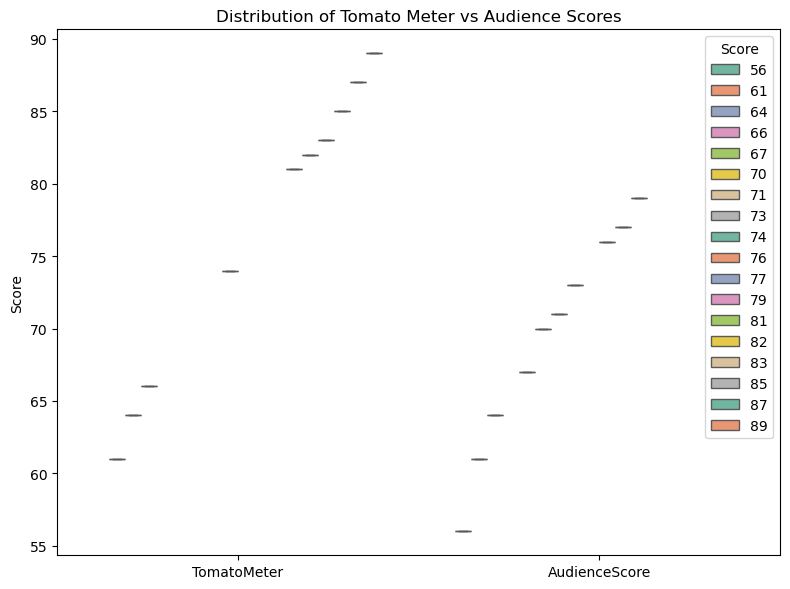

In [14]:
#prepare a sample ratings DataFrame (reuse existing mcu_df titles)
movies = mcu_df['Title'].tolist()
tomato_scores = (mcu_df['Duration'] % 30) + 60      # synthetic Tomato Meter (60-89)
audience_scores = (mcu_df['Duration'] % 25) + 55    # synthetic Audience Score (55-79)

ratings_df = pd.DataFrame({
    'Movie': movies,
    'TomatoMeter': tomato_scores,
    'AudienceScore': audience_scores
})

# melt into long format
ratings_melt = ratings_df.melt(id_vars='Movie',
                              value_vars=['TomatoMeter', 'AudienceScore'],
                              var_name='Source',
                              value_name='Score')

# boxplot comparison
plt.figure(figsize=(8, 6))
sns.boxplot(x='Source', y='Score', data=ratings_melt, palette='Set2', hue='Score')
plt.title('Distribution of Tomato Meter vs Audience Scores')
plt.xlabel('')
plt.tight_layout()
plt.show()

### **Exercice 6**

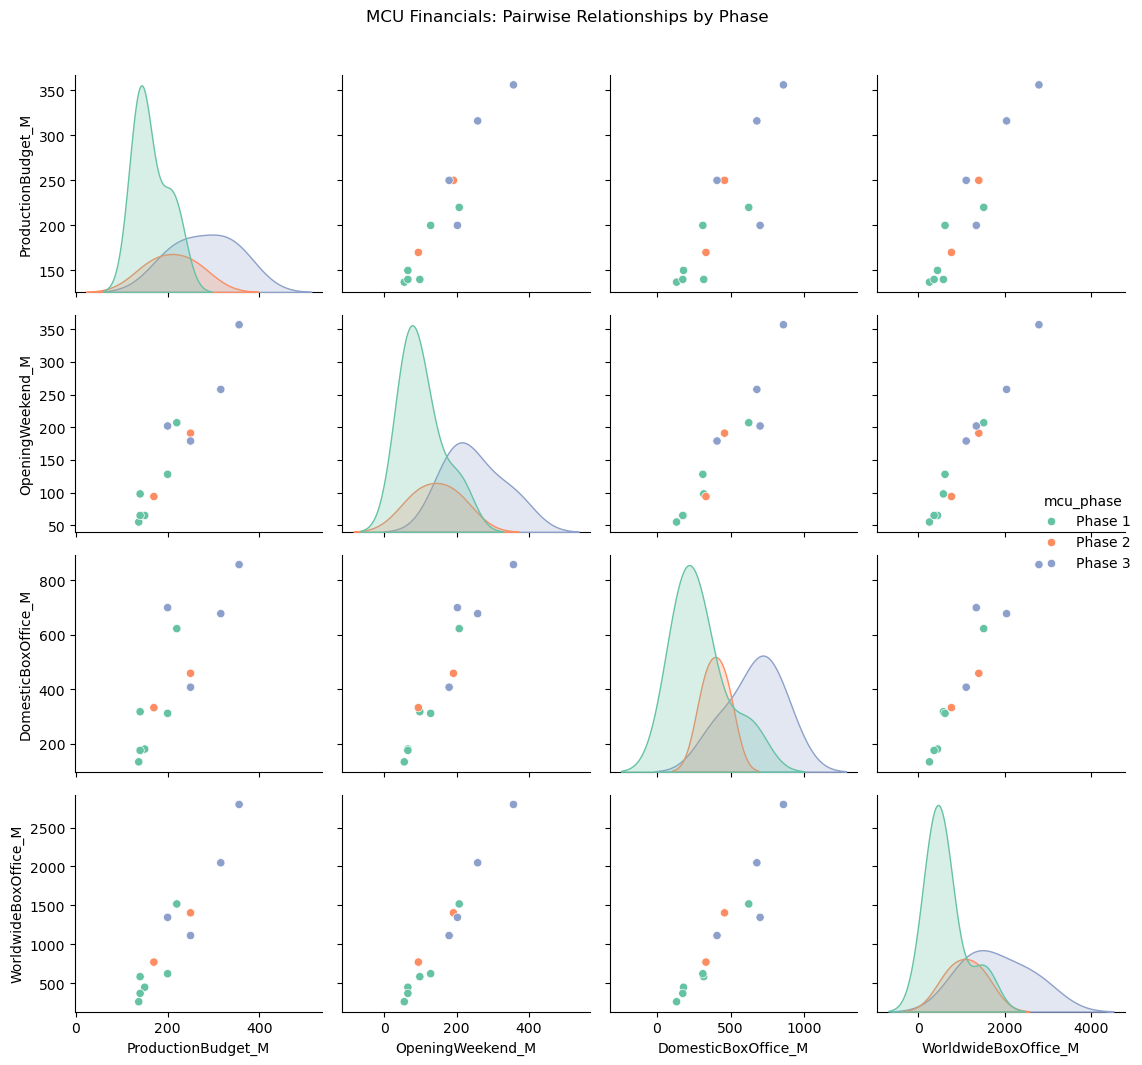

In [16]:
# build a synthetic financials table for the MCU titles (uses existing mcu_df)
titles = mcu_df['Title'].tolist()

prod_budgets = [
    140_000_000, 137_000_000, 200_000_000, 150_000_000,
    140_000_000, 220_000_000, 170_000_000, 250_000_000,
    250_000_000, 200_000_000, 316_000_000, 356_000_000
]
opening_weekends = [
    98_000_000, 55_000_000, 128_000_000, 65_000_000,
    65_000_000, 207_000_000, 94_000_000, 191_000_000,
    179_000_000, 202_000_000, 258_000_000, 357_000_000
]
domestic = [
    318_000_000, 134_000_000, 312_000_000, 181_000_000,
    176_000_000, 623_000_000, 333_000_000, 459_000_000,
    408_000_000, 700_000_000, 678_000_000, 858_000_000
]
worldwide = [
    585_000_000, 263_000_000, 623_000_000, 449_000_000,
    370_000_000, 1_519_000_000, 772_000_000, 1_405_000_000,
    1_113_000_000, 1_347_000_000, 2_048_000_000, 2_797_000_000
]
mcu_phase = [
    'Phase 1','Phase 1','Phase 1','Phase 1','Phase 1','Phase 1',
    'Phase 2','Phase 2','Phase 3','Phase 3','Phase 3','Phase 3'
]

# create DataFrame (use strings to demonstrate conversion if needed)
fin_df = pd.DataFrame({
    'Title': titles,
    'ProductionBudget': [f'${v:,}' for v in prod_budgets],
    'OpeningWeekend': [f'${v:,}' for v in opening_weekends],
    'DomesticBoxOffice': [f'${v:,}' for v in domestic],
    'WorldwideBoxOffice': [f'${v:,}' for v in worldwide],
    'mcu_phase': mcu_phase
})

# convert financial strings to numeric (millions)
money_cols = ['ProductionBudget','OpeningWeekend','DomesticBoxOffice','WorldwideBoxOffice']
fin_df[money_cols] = fin_df[money_cols].replace('[$,]', '', regex=True).astype(float) / 1e6
fin_df = fin_df.rename(columns={
    'ProductionBudget': 'ProductionBudget_M',
    'OpeningWeekend': 'OpeningWeekend_M',
    'DomesticBoxOffice': 'DomesticBoxOffice_M',
    'WorldwideBoxOffice': 'WorldwideBoxOffice_M'
})

# pairplot of selected metrics colored by MCU phase
vars_to_plot = ['ProductionBudget_M','OpeningWeekend_M','DomesticBoxOffice_M','WorldwideBoxOffice_M']
g = sns.pairplot(fin_df, vars=vars_to_plot, hue='mcu_phase', diag_kind='kde', height=2.6, palette='Set2')
g.fig.suptitle('MCU Financials: Pairwise Relationships by Phase', y=1.02)
plt.tight_layout()
plt.show()